In [327]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, accuracy_score, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Datan kuvailu ja preprosessointi
1. luokitellaan data sen sisällön mukaan.

In [311]:
#Määritetään tyypit kaikille attribuuteille

df = pd.read_csv('puut1.csv', 
                 index_col=0,
                 dtype={
                   "length": np.float64,
                   "diameter": np.float64,
                   "cones": np.int64,
                   "leaves": np.int64,
                   "bark_thickness": np.float64,
                   "seed_size": np.float64,
                   "fungi_present": np.bool,
                   "color_guess": np.object_,
                   "soil_pH": np.float64,
                   "collector_id": np.float64,
                   "collector_guess": np.float64,
                   }, 
                   na_values="*"
                   )

2. Tarkistetaan datan eheys

In [312]:
#Tarkistetaan onko datassa puuttuvia arvoja
print(df.isnull().sum())

numeric_vars = ["length", "diameter", "cones", "leaves", "bark_thickness", "seed_size", "soil_pH"]
categoric_vars = ["fungi_present", "color_guess"]
researcher_vars = ["collector_guess", "collector_id"]

length             0
diameter           0
cones              0
leaves             0
bark_thickness     0
seed_size          0
fungi_present      0
color_guess        0
soil_pH            0
collector_id       0
collector_guess    0
dtype: int64


In [313]:
#Tulostetaan numeeriset attribuutit ja tarkastellaan tulostusta
print(df[numeric_vars].describe())

           length    diameter       cones        leaves  bark_thickness  \
count  300.000000  300.000000  300.000000    300.000000       300.00000   
mean   267.447867  115.530267   87.836667  10689.056667         1.15890   
std     78.856833   24.844247   58.511840   5691.384465         0.27241   
min     69.080000   73.960000  -10.000000   1067.000000         0.62000   
25%    207.400000   98.310000   35.750000   5720.000000         0.98000   
50%    289.565000  105.575000   85.500000  10631.000000         1.09000   
75%    306.410000  130.832500  131.250000  15620.500000         1.31000   
max    516.900000  214.820000  199.000000  19956.000000         2.25000   

        seed_size     soil_pH  
count  300.000000  300.000000  
mean     1.000222    7.990200  
std      0.019324    1.040056  
min      0.833844    4.850000  
25%      0.998046    7.320000  
50%      1.000088    8.020000  
75%      1.001857    8.630000  
max      1.158028   11.850000  


In [314]:
#Tulostetaan kategoriset attribuutit ja tarkastellaan tulostusta
print(df[categoric_vars + researcher_vars].astype('object').describe())

       fungi_present color_guess  collector_guess  collector_id
count            300         300            300.0         300.0
unique             2           5              3.0           3.0
top            False    lightish              2.0           1.0
freq             154          76            123.0         102.0


In [315]:
#Tarkistetaan kategoriset muuttujat turhien luokkien varalta
for col in df[categoric_vars + researcher_vars]:
  print(f"{col:<15}: {df[col].unique()}")

fungi_present  : [False  True]
color_guess    : ['dark' 'light' 'mid-green' 'lightish' 'darkish']
collector_guess: [1. 2. 3.]
collector_id   : [3. 2. 1.]


In [316]:
#Korjataan virheelliset arvot käpyjen määrässä.
#Käpyjä ei voi olla negatiivista määrää.
#Oletetaan että negatiivinen etuliite on kirjoitettu vahingossa.
#Muutetaan siis kaikki arvot niiden itsearvoiksi käpyjen määrän sarakkeessa.
df.cones = df.cones.abs()

3. Datan kuvailu tilastollisilla menetelmillä

Monet tilastolliset menetelmät olettavat että data on riippumatonta ja normaalisti jakautunutta. Testataan aluksi datan jakaumaa, jonka jälkeen sovelletaan testejä dataan perustuen kuinka se on jakautunut. Tärkeimmät testit tässä tapauksessa ovat korrelaatiotestit, joiden avulla selvitetään minkä attribuuttien yhdistelmät tuottavat tarpeeksi korreloitunutta tulosta.

Korkean korrelaation attribuutit voidaan valita seuraavassa kohdassa KMeans klusteroinnin parametreiksi, jotta klusterointi olisi tehokasta. Tehokkuuteen vaikuttaa kuinka paljon attribuutit vaikuttavat attribuuttien väliseen korrelaatioon.

Kuvailun jälkeen data normalisoidaan, jotta etäisyyteen perustuvat menetelmät toimivat eri mittaluokan attribuuteilla.

In [317]:
df['fungi_present'] = df['fungi_present'].replace([False, True], [0, 1])
df['color_guess'] = df['color_guess'].replace(
  ['dark', 'light', 'mid-green', 'lightish', 'darkish'],
  [0, 4, 2, 3, 1]
  )

In [318]:
#Käytetään Shapiro-Wilkin normaalisuus testiä numeerisen datan analysoinnissa
shapiro_test = stats.shapiro(df[numeric_vars], axis=0)
print(f'P-arvot numeeriselle datalle:')
for index, row in enumerate(shapiro_test.pvalue):
  print(f'{df[numeric_vars].columns[index]:<15} {row:<8.3} {"< 0.05" if row < 0.05  else "> 0.05"}')

P-arvot numeeriselle datalle:
length          8.83e-08 < 0.05
diameter        9.83e-15 < 0.05
cones           1.62e-08 < 0.05
leaves          6.92e-09 < 0.05
bark_thickness  4.17e-09 < 0.05
seed_size       3.07e-29 < 0.05
soil_pH         0.37     > 0.05


In [319]:
#Koska kaikki attribuutit eivät ole normaalisti jakautuneita, 
#käytetään Spearmannin korrelaatiokerrointa
numeric_correlation = []

for col in df[numeric_vars + categoric_vars]:
  print(f'Spearman Correlation for {col} and')
  for col2 in df[numeric_vars + categoric_vars]:
    if(col == col2):
      continue
    spearman_corr = df[col].corr(df[col2], method='spearman')
    numeric_correlation.append((spearman_corr, f"correlation of {col} and {col2}"))
    print(f'{col2:<15} {spearman_corr:<8.3} {"< 0.5" if abs(spearman_corr) < 0.5  else "> 0.5"}')
  print()

Spearman Correlation for length and
diameter        0.196    < 0.5
cones           0.0416   < 0.5
leaves          -0.0704  < 0.5
bark_thickness  0.179    < 0.5
seed_size       -0.0247  < 0.5
soil_pH         -0.0416  < 0.5
fungi_present   0.0742   < 0.5
color_guess     0.0413   < 0.5

Spearman Correlation for diameter and
length          0.196    < 0.5
cones           0.0647   < 0.5
leaves          0.0101   < 0.5
bark_thickness  0.859    > 0.5
seed_size       -0.073   < 0.5
soil_pH         -0.0293  < 0.5
fungi_present   0.245    < 0.5
color_guess     -0.0353  < 0.5

Spearman Correlation for cones and
length          0.0416   < 0.5
diameter        0.0647   < 0.5
leaves          0.0323   < 0.5
bark_thickness  0.0448   < 0.5
seed_size       0.0448   < 0.5
soil_pH         0.0679   < 0.5
fungi_present   -0.0167  < 0.5
color_guess     0.108    < 0.5

Spearman Correlation for leaves and
length          -0.0704  < 0.5
diameter        0.0101   < 0.5
cones           0.0323   < 0.5
bark_thickness 

In [320]:
#Tulostetaan viisi eniten korreloitunutta attribuuttia

numeric_correlation = sorted(numeric_correlation, key=lambda x: x[0], reverse=True)
top5 = []

for index, row in enumerate(numeric_correlation):
  if(index % 2 == 0):
    continue
  if(index >= 10):
    break
  top5.append(row)

for row in top5:
  print(f'{row[1]:<50}: {row[0]:.4}')

correlation of bark_thickness and diameter        : 0.8587
correlation of fungi_present and diameter         : 0.2451
correlation of fungi_present and bark_thickness   : 0.2262
correlation of diameter and length                : 0.1959
correlation of bark_thickness and length          : 0.1786


In [321]:
#Muodostetaan merkittävimpien attribuuttien lista
cluster_vars = ['bark_thickness', 'diameter', 'fungi_present']

#Normalisoidaan data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_vars])

# 2 Tutkimus
1. Käytetään KMeans klusterointia ja jaetaan puut kolmeen luokkaan

In [322]:
kmeans = KMeans(n_clusters=3,
                init='k-means++',
                n_init=150,
                max_iter=5000,
                random_state=42
                )
kmeans.fit(X_scaled)

df['cluster'] = kmeans.labels_

In [323]:
df[numeric_vars + categoric_vars + ['cluster']].groupby('cluster').mean()

,length,diameter,cones,leaves,bark_thickness,seed_size,soil_pH,fungi_present,color_guess
cluster,,,,,,,,,
0,293.249306,153.531111,93.916667,11269.736111,1.548750,0.997352,7.930556,0.722222,2.180556
1,255.967985,102.425373,89.067164,10569.238806,1.025970,1.001342,8.019104,0.0,2.067164
2,264.050000,105.104681,82.382979,10415.085106,1.049787,1.000825,7.994681,1.0,2.106383


In [324]:
score = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")  # Closer to 1.0 is better

sample_scores = silhouette_samples(X_scaled, kmeans.labels_)
for cluster in range(3):
    cluster_scores = sample_scores[kmeans.labels_ == cluster]
    print(f"Cluster {cluster}: mean={cluster_scores.mean():.3f}, "
          f"min={cluster_scores.min():.3f}")

Silhouette Score: 0.555
Cluster 0: mean=0.365, min=-0.078
Cluster 1: mean=0.671, min=0.203
Cluster 2: mean=0.536, min=0.139


bark_thickness    1.0
diameter          1.0
fungi_present     1.0
dtype: float64


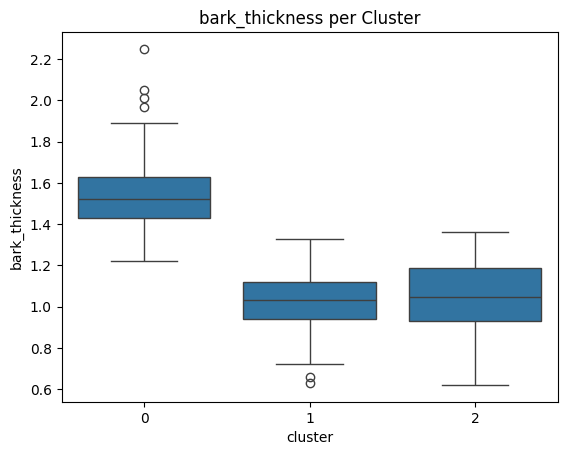

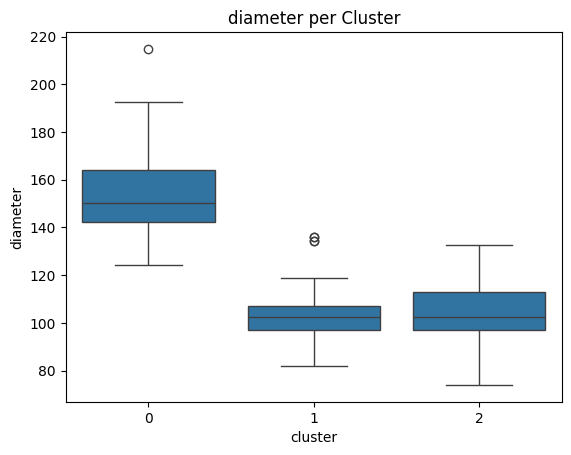

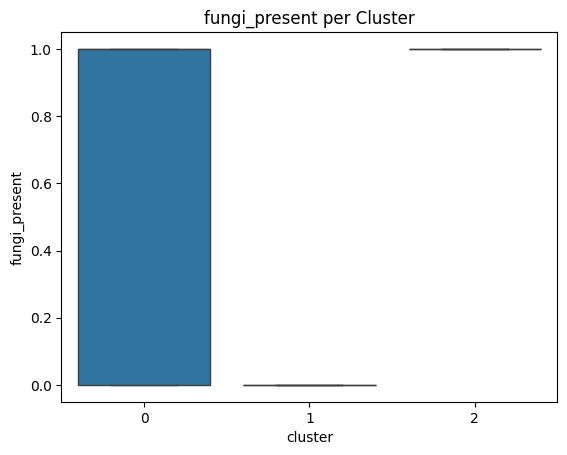

In [325]:
variances = pd.Series(X_scaled.var(axis=0), index=cluster_vars)
print(variances.sort_values())

# Visualize feature distributions per cluster
df['cluster'] = kmeans.labels_
for feature in cluster_vars:
    sns.boxplot(data=df, x='cluster', y=feature)
    plt.title(f'{feature} per Cluster')
    plt.show()

In [326]:
# Calculate accuracy for each researcher
researcher_accuracy = df.groupby('collector_id').apply(
    lambda x: accuracy_score(x['cluster'], x['collector_guess'])
).reset_index()

researcher_accuracy.columns = ['collector_id', 'accuracy']
researcher_accuracy = researcher_accuracy.sort_values('accuracy', ascending=False)

print(researcher_accuracy)

   collector_id  accuracy
2           3.0  0.260000
1           2.0  0.214286
0           1.0  0.166667


In [331]:
for researcher in df['collector_id'].unique():
    subset = df[df['collector_id'] == researcher]
    print(f"\n{'='*40}")
    print(f"Researcher: {researcher}")
    print(f"{'='*40}")
    print(classification_report(
        subset['cluster'],
        subset['collector_guess'],
        zero_division=0
    ))


Researcher: 3.0
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        29
         1.0       0.12      0.05      0.07        41
         2.0       0.35      0.80      0.49        30
         3.0       0.00      0.00      0.00         0

    accuracy                           0.26       100
   macro avg       0.12      0.21      0.14       100
weighted avg       0.16      0.26      0.18       100


Researcher: 2.0
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        21
         1.0       0.25      0.24      0.24        46
         2.0       0.48      0.32      0.38        31
         3.0       0.00      0.00      0.00         0

    accuracy                           0.21        98
   macro avg       0.18      0.14      0.16        98
weighted avg       0.27      0.21      0.24        98


Researcher: 1.0
              precision    recall  f1-score   support

         0.0       0.00 

In [334]:
from sklearn.metrics import f1_score

summary = df.groupby('collector_id').apply(lambda x: pd.Series({
    'total_samples' : len(x),
    'correct'       : (x['cluster'] == x['collector_guess']).sum(),
    'accuracy'      : accuracy_score(x['cluster'], x['collector_guess']),
    'f1_score'      : f1_score(x['cluster'], x['collector_guess'],
                               average='weighted', zero_division=0)
})).reset_index().sort_values('accuracy', ascending=False)

print(summary)

   collector_id  total_samples  correct  accuracy  f1_score
2           3.0          100.0     26.0  0.260000  0.175711
1           2.0           98.0     21.0  0.214286  0.236403
0           1.0          102.0     17.0  0.166667  0.168494


/tmp/ipykernel_1915/4244458915.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


KeyError: 'researcher_id'

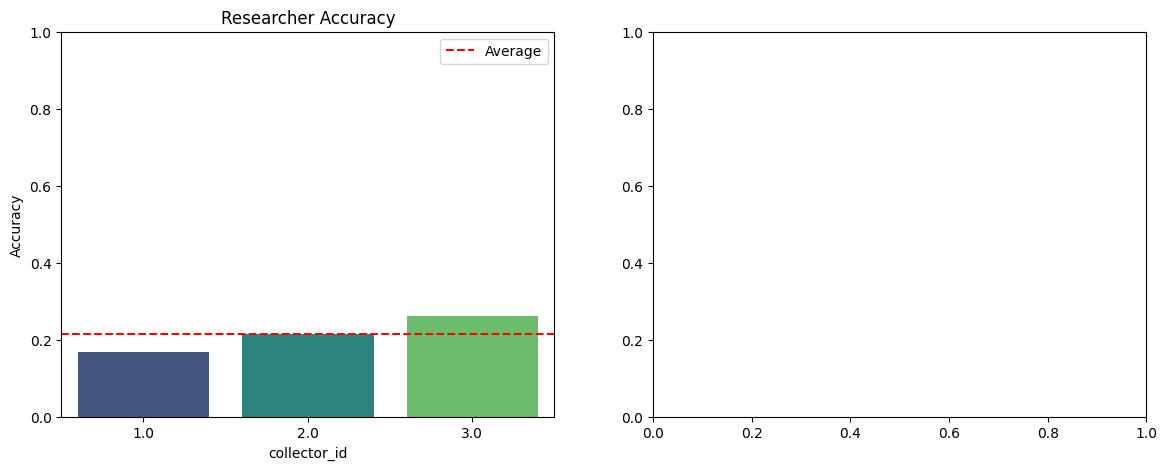

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy Leaderboard ---
sns.barplot(
    data=summary,
    x='collector_id',
    y='accuracy',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Researcher Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=summary['accuracy'].mean(), color='red',
                linestyle='--', label='Average')
axes[0].legend()

# --- Plot 2: Confusion Heatmap Per Researcher ---
for researcher in df['collector_id'].unique():
    subset = df[df['collector_id'] == researcher]
    conf_matrix = pd.crosstab(
        subset['cluster'],
        subset['collector_guess'],
        rownames=['Actual'],
        colnames=['Predicted']
    )
    sns.heatmap(conf_matrix, annot=True, fmt='d',
                cmap='Blues', ax=axes[1])
    axes[1].set_title(f'Confusion Matrix - {researcher}')

plt.tight_layout()
plt.show()